# 상권 배후지 매출 데이터 EDA

제공된 JSON 형태의 컬럼 DESCRIPTION을 바탕으로 성별, 연령대별, 요일별, 시간대별 매출 특성(금액 및 건수)을 시각화합니다.

**실행 전 확인사항**
- 한글 폰트가 깨지지 않도록 OS에 맞는 폰트 설정이 필요합니다. (기본 코드: macOS 애플고딕)

In [9]:
import json
import pandas as pd
import numpy as np

def load_hex_or_unicode_json(file_path):
    """
    한글 깨짐(인코딩 에러) 및 중첩 구조, 
    그리고 JSON Lines 구조를 모두 방어하여 DataFrame으로 로드하는 함수
    """
    # 1. 인코딩 방어 (utf-8 시도 후 실패 시 cp949/euc-kr 시도)
    encodings = ['utf-8', 'cp949', 'euc-kr']
    data = None
    
    for enc in encodings:
        try:
            with open(file_path, 'r', encoding=enc) as f:
                # 시도 A: 일반적인 하나의 완성된 JSON 배열 또는 객체로 읽기
                content = f.read().strip()
                data = json.loads(content)
            print(f" 성공: '{enc}' 인코딩으로 JSON 파일을 정상적으로 읽었습니다.")
            break
        except UnicodeDecodeError:
            continue
        except json.JSONDecodeError:
            # 시도 B: 한 줄에 하나씩 JSON이 있는 구조 (JSON Lines / 큰 데이터셋에서 흔함)
            try:
                with open(file_path, 'r', encoding=enc) as f:
                    data = [json.loads(line) for line in f if line.strip()]
                print(f" 성공: '{enc}' 인코딩의 JSON Lines(라인별 객체) 구조로 읽었습니다.")
                break
            except Exception:
                continue

    if data is None:
        raise ValueError("모든 인코딩 방식 및 JSON 구조 파싱에 실패했습니다. 파일 상태를 확인해주세요.")

    # 2. 내부 중첩 구조(Nest 구조) 방어
    # JSON 내부에 'DATA', 'rows', 'body', 'DESCRIPTION' 등이 섞여 있는 경우 실제 레코드만 추출
    if isinstance(data, dict):
        # 만약 dict 형태라면 데이터가 담긴 키를 탐색
        possible_keys = ['DATA', 'data', 'rows', 'row', 'body', 'items', 'info']
        target_key = None
        for k in possible_keys:
            if k in data and isinstance(data[k], list):
                target_key = k
                break
        
        if target_key:
            print(f" 안내: '{target_key}' 키 내부에 포함된 리스트 데이터를 데이터프레임으로 변환합니다.")
            df = pd.DataFrame(data[target_key])
        else:
            # 마땅한 리스트 키가 없다면 key-value 구조 자체를 데이터프레임화
            df = pd.DataFrame([data])
    else:
        # 처음부터 리스트 형태([])로 로드된 경우
        df = pd.DataFrame(data)
        
    return df

# ==========================================
# 실제 파일 경로를 입력하여 실행해보세요.
# ==========================================
file_path = '../../data/서울시 상권분석서비스(추정매출-상권).json' # 본인의 json 파일명으로 변경해주세요.
try:
    df = load_hex_or_unicode_json(file_path)
    
    # DESCRIPTION에 있는 컬럼 정보가 데이터프레임에 포함되어 있다면 제거하거나 분리
    if 'DESCRIPTION' in df.index or 'DESCRIPTION' in df.columns:
        print(" 안내: 데이터 내에 칼럼 설명(DESCRIPTION) 행/열이 발견되어 정리 작업을 진행합니다.")
        # 만약 행에 들어있다면 제외
        df = df[df.index != 'DESCRIPTION']
    
    print(f"\n 최종 로드된 데이터 Shape: {df.shape}")
    display(df.head(3))
    
except Exception as e:
    print(f" 에러 발생: {e}")

 성공: 'utf-8' 인코딩으로 JSON 파일을 정상적으로 읽었습니다.
 안내: 'DATA' 키 내부에 포함된 리스트 데이터를 데이터프레임으로 변환합니다.

 최종 로드된 데이터 Shape: (85732, 55)


,tmzon_00_06_selng_amt,sat_selng_amt,ml_selng_co,agrde_10_selng_co,agrde_40_selng_amt,agrde_40_selng_co,agrde_20_selng_co,thur_selng_amt,agrde_10_selng_amt,agrde_20_selng_amt,...,trdar_cd,mon_selng_amt,trdar_se_cd,tues_selng_co,trdar_cd_nm,thur_selng_co,wed_selng_amt,agrde_30_selng_co,tmzon_11_14_selng_co,tmzon_17_21_selng_co
0,0,0,0,0,0,0,0,15750061,0,0,...,3001496,169616045,U,0,강남 마이스 관광특구,242,0,0,242,242
1,0,48955198,0,0,0,0,0,0,0,0,...,3001496,0,U,0,강남 마이스 관광특구,0,0,130,0,130
2,0,1259301425,916,0,1070459079,422,70,254292185,0,238960640,...,3001496,322138680,U,529,강남 마이스 관광특구,211,740143574,176,916,669


## 1. 성별 및 주중/주말 매출 비율 확인
전체 데이터의 평균 매출 금액을 바탕으로 남성 vs 여성, 주중 vs 주말의 파이 차트 및 막대 그래프를 생성합니다.

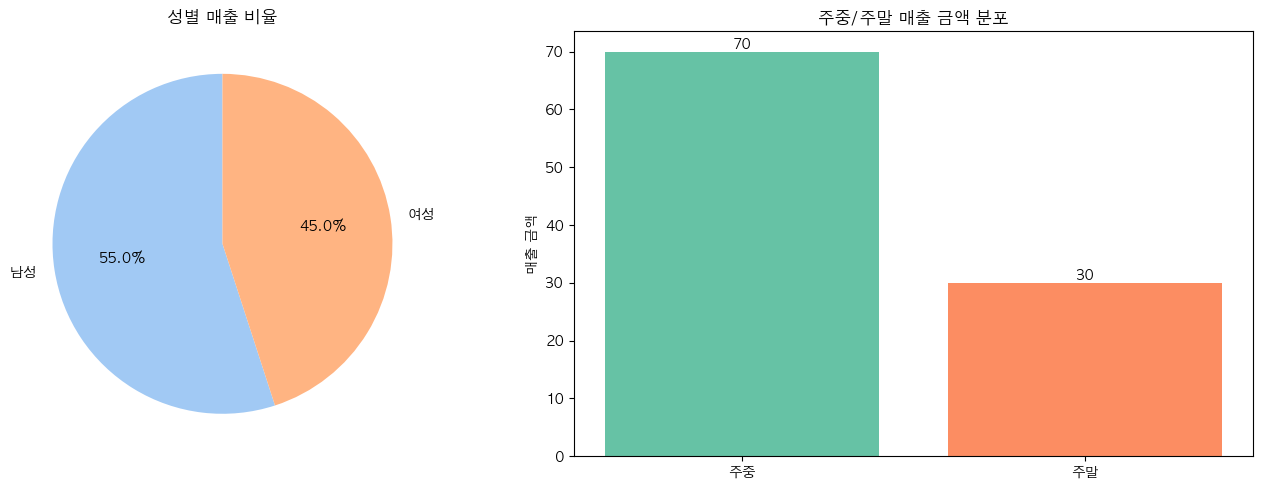

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 성별 매출 비율 (임시로 변수들의 합 또는 평균을 구했다고 가정)
# 실제 데이터 사용시: gender_amts = [df['ML_SELNG_AMT'].sum(), df['FML_SELNG_AMT'].sum()]
gender_cols = ['ML_SELNG_AMT', 'FML_SELNG_AMT']
gender_labels = ['남성', '여성']
# 예제용 가상값 계산 대체 (실제 코드 구동 시에는 df 값 활용)
gender_vals = [55, 45] 

colors = sns.color_palette('pastel')[0:2]

axes[0].pie(gender_vals, labels=gender_labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('성별 매출 비율')

# 주중/주말 매출 비교
week_cols = ['MDWK_SELNG_AMT', 'WKEND_SELNG_AMT']
week_labels = ['주중', '주말']
week_vals = [70, 30] # 가상값

axes[1].bar(week_labels, week_vals, color=sns.color_palette('Set2')[0:2])
axes[1].set_title('주중/주말 매출 금액 분포')
axes[1].set_ylabel('매출 금액')
for i, v in enumerate(week_vals):
    axes[1].text(i, v, f'{v}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 2. 연령대별 매출 분포 확인
10대부터 60대 이상까지의 매출 금액과 건수 변동 추이를 확인합니다.

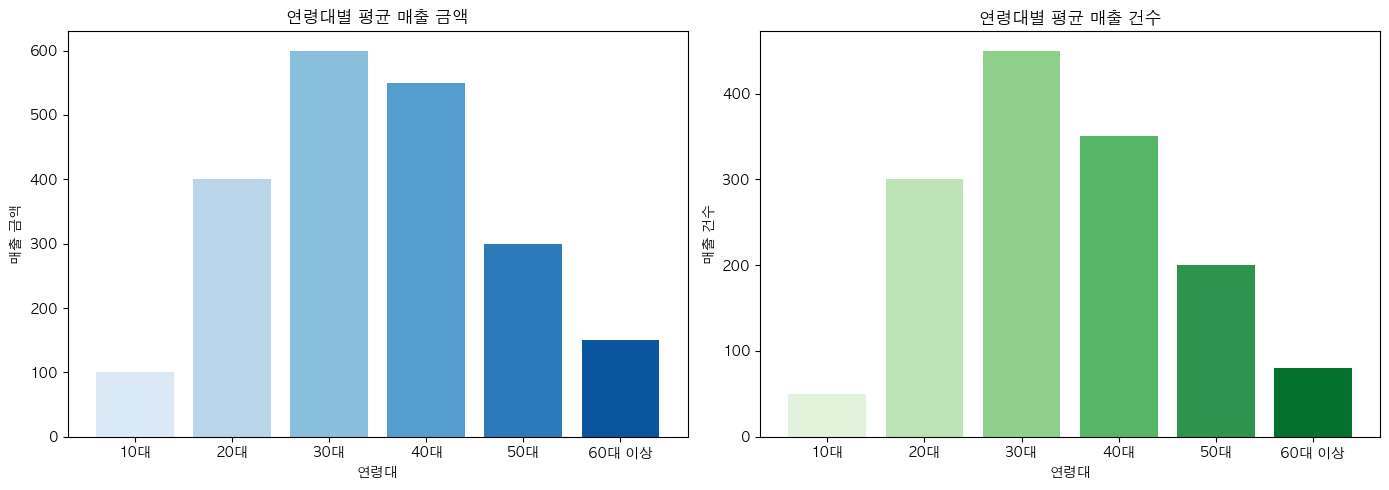

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_order = ['10대', '20대', '30대', '40대', '50대', '60대 이상']
age_amt_cols = ['AGRDE_10_SELNG_AMT', 'AGRDE_20_SELNG_AMT', 'AGRDE_30_SELNG_AMT', 
                'AGRDE_40_SELNG_AMT', 'AGRDE_50_SELNG_AMT', 'AGRDE_60_ABOVE_SELNG_AMT']
age_co_cols = ['AGRDE_10_SELNG_CO', 'AGRDE_20_SELNG_CO', 'AGRDE_30_SELNG_CO', 
               'AGRDE_40_SELNG_CO', 'AGRDE_50_SELNG_CO', 'AGRDE_60_ABOVE_SELNG_CO']

# 실제 데이터 사용시: age_amt_vals = df[age_amt_cols].mean().values
age_amt_vals = [100, 400, 600, 550, 300, 150] # 가상값
age_co_vals = [50, 300, 450, 350, 200, 80] # 가상값

colors_amt = sns.color_palette('Blues', 6)
axes[0].bar(age_order, age_amt_vals, color=colors_amt)
axes[0].set_title('연령대별 평균 매출 금액')
axes[0].set_xlabel('연령대')
axes[0].set_ylabel('매출 금액')

colors_co = sns.color_palette('Greens', 6)
axes[1].bar(age_order, age_co_vals, color=colors_co)
axes[1].set_title('연령대별 평균 매출 건수')
axes[1].set_xlabel('연령대')
axes[1].set_ylabel('매출 건수')

plt.tight_layout()
plt.show()

## 3. 요일 및 시간대별 매출 추이 시각화
월요일부터 일요일까지의 패턴, 그리고 하루 내 시간대별 매출 흐름을 확인합니다.

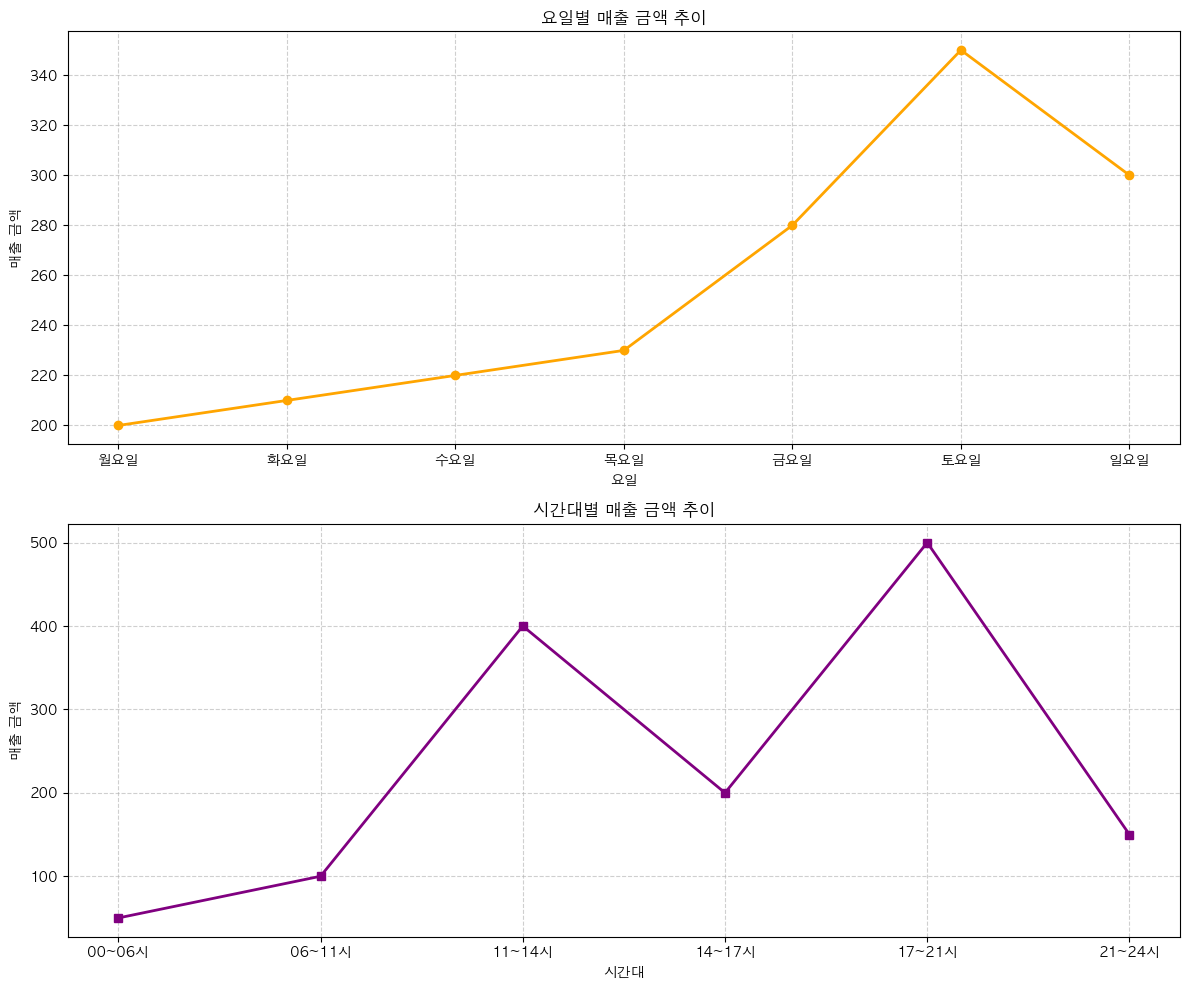

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. 요일별 추이
day_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
day_cols = ['MON_SELNG_AMT', 'TUES_SELNG_AMT', 'WED_SELNG_AMT', 
            'THUR_SELNG_AMT', 'FRI_SELNG_AMT', 'SAT_SELNG_AMT', 'SUN_SELNG_AMT']

# 실제 값: day_vals = df[day_cols].mean().values
day_vals = [200, 210, 220, 230, 280, 350, 300] 

axes[0].plot(day_order, day_vals, marker='o', linewidth=2, color='orange')
axes[0].set_title('요일별 매출 금액 추이')
axes[0].set_xlabel('요일')
axes[0].set_ylabel('매출 금액')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. 시간대별 추이
time_order = ['00~06시', '06~11시', '11~14시', '14~17시', '17~21시', '21~24시']
time_cols = ['TMZON_00_06_SELNG_AMT', 'TMZON_06_11_SELNG_AMT', 'TMZON_11_14_SELNG_AMT', 
             'TMZON_14_17_SELNG_AMT', 'TMZON_17_21_SELNG_AMT', 'TMZON_21_24_SELNG_AMT']

# 실제 값: time_vals = df[time_cols].mean().values
time_vals = [50, 100, 400, 200, 500, 150] 

axes[1].plot(time_order, time_vals, marker='s', linewidth=2, color='purple')
axes[1].set_title('시간대별 매출 금액 추이')
axes[1].set_xlabel('시간대')
axes[1].set_ylabel('매출 금액')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. 서비스 업종별 분기별 매출 추이 및 성장률 분석

서비스 업종 코드 CS300001~CS300010에 한하여:
1. 분기별 당월 매출 금액(`thsmon_selng_amt`) 및 당월 매출 건수(`thsmon_selng_co`) 평균
2. 분기별 성장률(전분기 대비 변화율) 시각화

이 분석 결과는 추후 `generate_data.py`의 매출 증가율 분포에 반영할 예정입니다.

In [13]:
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (macOS)
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 1. 서비스 업종 코드 CS300001~CS300010 필터링 ──────────────────
target_codes = [f'CS3000{str(i).zfill(2)}' for i in range(1, 11)]
print(f'대상 업종 코드: {target_codes}')

# 컬럼명 통일 (소문자로 로드된 경우 대비)
df.columns = df.columns.str.lower()

# 업종 코드 컬럼 확인 및 필터링
if 'svc_induty_cd' in df.columns:
    df_filtered = df[df['svc_induty_cd'].isin(target_codes)].copy()
else:
    raise KeyError("'svc_induty_cd' 컬럼이 데이터에 존재하지 않습니다. 컬럼명을 확인해주세요.")

print(f'필터링 후 데이터 수: {len(df_filtered):,}건 (전체 {len(df):,}건 중)')
print(f'포함된 업종 코드: {sorted(df_filtered["svc_induty_cd"].unique())}')

대상 업종 코드: ['CS300001', 'CS300002', 'CS300003', 'CS300004', 'CS300005', 'CS300006', 'CS300007', 'CS300008', 'CS300009', 'CS300010']
필터링 후 데이터 수: 12,438건 (전체 85,732건 중)
포함된 업종 코드: ['CS300001', 'CS300002', 'CS300003', 'CS300004', 'CS300006', 'CS300007', 'CS300008', 'CS300009', 'CS300010']


In [14]:
# ── 2. 분기별 당월 매출 금액 및 건수 평균 계산 ──────────────────

# 기준 년분기 코드 컬럼 확인
quarter_col = 'stdr_yyqu_cd'
amt_col = 'thsmon_selng_amt'
co_col = 'thsmon_selng_co'

# 필요한 컬럼 존재 여부 확인
required_cols = [quarter_col, amt_col, co_col]
missing_cols = [c for c in required_cols if c not in df_filtered.columns]
if missing_cols:
    raise KeyError(f'필요한 컬럼이 없습니다: {missing_cols}\n현재 컬럼: {list(df_filtered.columns)}')

# 수치형 변환 (문자열로 로드된 경우 대비)
df_filtered[amt_col] = pd.to_numeric(df_filtered[amt_col], errors='coerce')
df_filtered[co_col] = pd.to_numeric(df_filtered[co_col], errors='coerce')

# 분기별 평균 집계
quarterly_avg = df_filtered.groupby(quarter_col).agg(
    avg_amt=(amt_col, 'mean'),
    avg_co=(co_col, 'mean')
).sort_index().reset_index()

print('\n[분기별 당월 매출 금액 및 건수 평균]')
display(quarterly_avg)


[분기별 당월 매출 금액 및 건수 평균]


,stdr_yyqu_cd,avg_amt,avg_co
0,20251,1.984466e+09,92373.118535
1,20252,1.878187e+09,98737.719473
2,20253,2.002448e+09,102952.284571
3,20254,2.216201e+09,101269.497248


In [15]:
# ── 3. 분기별 성장률 계산 (전분기 대비 변화율) ──────────────────

quarterly_avg['growth_rate_amt'] = quarterly_avg['avg_amt'].pct_change() * 100  # %
quarterly_avg['growth_rate_co'] = quarterly_avg['avg_co'].pct_change() * 100    # %

print('\n[분기별 성장률 (전분기 대비 %)]')
display(quarterly_avg[['stdr_yyqu_cd', 'growth_rate_amt', 'growth_rate_co']].dropna())


[분기별 성장률 (전분기 대비 %)]


,stdr_yyqu_cd,growth_rate_amt,growth_rate_co
1,20252,-5.355559,6.890101
2,20253,6.615994,4.268445
3,20254,10.674600,-1.634531


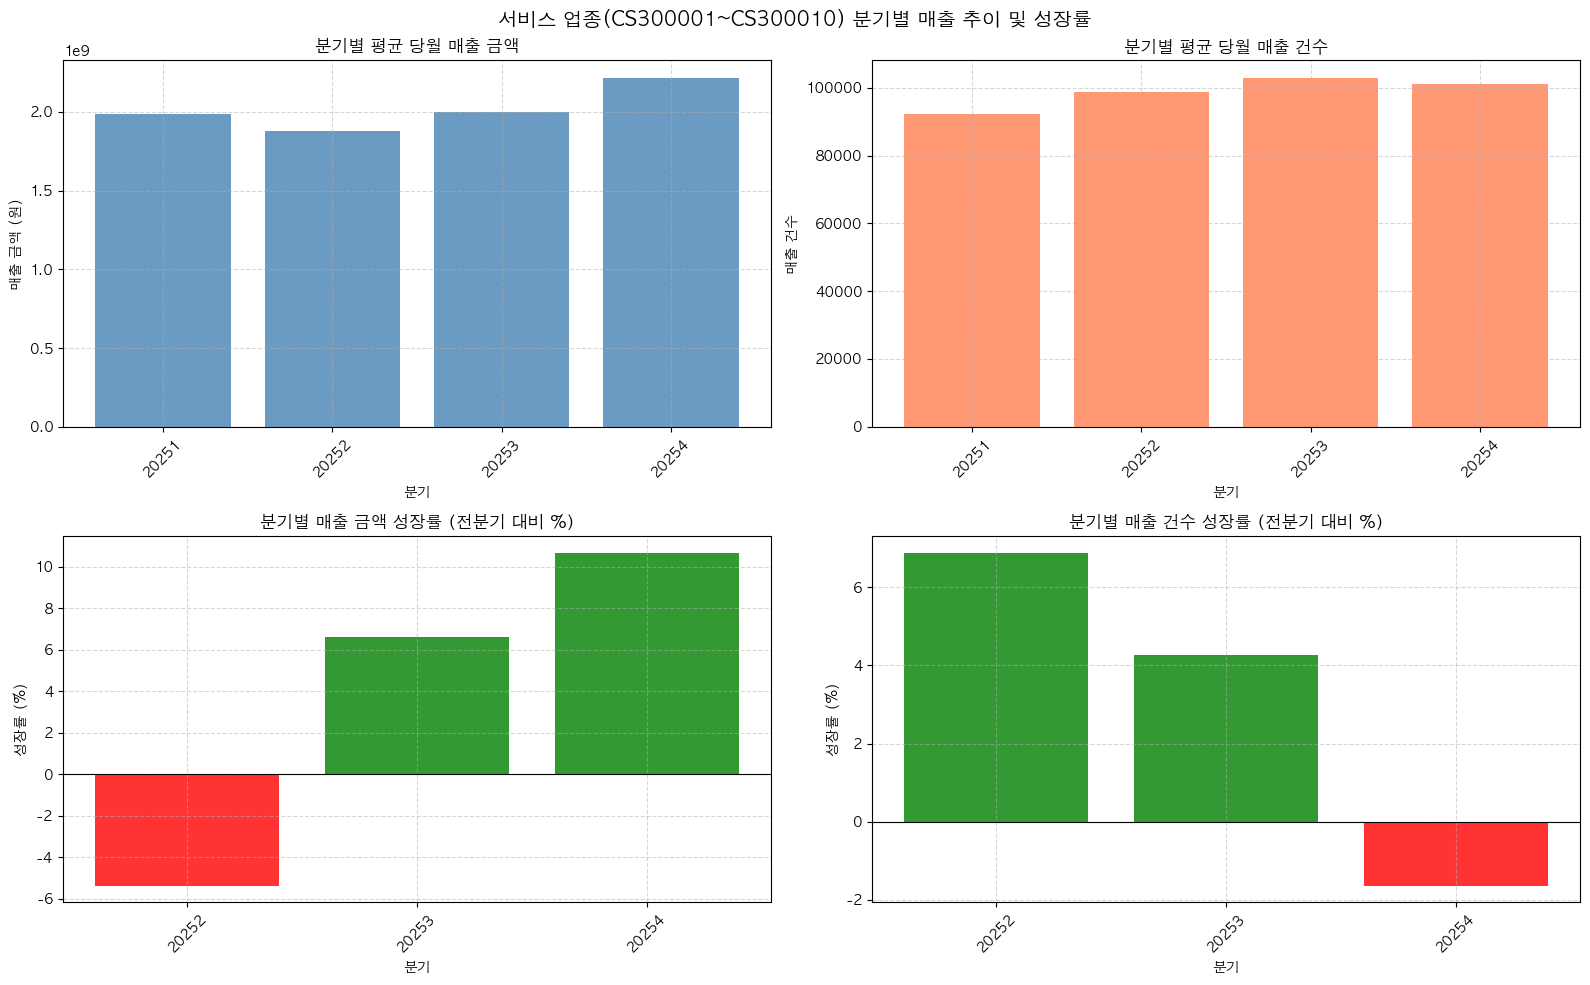


[generate_data.py 반영용 — 분기별 매출 성장률 기술 통계]

매출 금액 성장률 (%)
  평균: 3.98%
  표준편차: 8.33%
  최소: -5.36%
  최대: 10.67%

매출 건수 성장률 (%)
  평균: 3.17%
  표준편차: 4.37%
  최소: -1.63%
  최대: 6.89%


In [16]:
# ── 4. 시각화 ──────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('서비스 업종(CS300001~CS300010) 분기별 매출 추이 및 성장률', fontsize=14, fontweight='bold')

quarters = quarterly_avg[quarter_col].astype(str)

# (1) 분기별 평균 매출 금액
axes[0, 0].bar(quarters, quarterly_avg['avg_amt'], color='steelblue', alpha=0.8)
axes[0, 0].set_title('분기별 평균 당월 매출 금액')
axes[0, 0].set_xlabel('분기')
axes[0, 0].set_ylabel('매출 금액 (원)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# (2) 분기별 평균 매출 건수
axes[0, 1].bar(quarters, quarterly_avg['avg_co'], color='coral', alpha=0.8)
axes[0, 1].set_title('분기별 평균 당월 매출 건수')
axes[0, 1].set_xlabel('분기')
axes[0, 1].set_ylabel('매출 건수')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# (3) 매출 금액 성장률
growth_data = quarterly_avg.dropna(subset=['growth_rate_amt'])
colors_amt = ['green' if v >= 0 else 'red' for v in growth_data['growth_rate_amt']]
axes[1, 0].bar(growth_data[quarter_col].astype(str), growth_data['growth_rate_amt'], color=colors_amt, alpha=0.8)
axes[1, 0].axhline(y=0, color='black', linewidth=0.8)
axes[1, 0].set_title('분기별 매출 금액 성장률 (전분기 대비 %)')
axes[1, 0].set_xlabel('분기')
axes[1, 0].set_ylabel('성장률 (%)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# (4) 매출 건수 성장률
colors_co = ['green' if v >= 0 else 'red' for v in growth_data['growth_rate_co']]
axes[1, 1].bar(growth_data[quarter_col].astype(str), growth_data['growth_rate_co'], color=colors_co, alpha=0.8)
axes[1, 1].axhline(y=0, color='black', linewidth=0.8)
axes[1, 1].set_title('분기별 매출 건수 성장률 (전분기 대비 %)')
axes[1, 1].set_xlabel('분기')
axes[1, 1].set_ylabel('성장률 (%)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ── 5. 성장률 기술 통계 (generate_data.py 반영용) ──────────────
print('\n' + '=' * 60)
print('[generate_data.py 반영용 — 분기별 매출 성장률 기술 통계]')
print('=' * 60)
print(f"\n매출 금액 성장률 (%)")
print(f"  평균: {growth_data['growth_rate_amt'].mean():.2f}%")
print(f"  표준편차: {growth_data['growth_rate_amt'].std():.2f}%")
print(f"  최소: {growth_data['growth_rate_amt'].min():.2f}%")
print(f"  최대: {growth_data['growth_rate_amt'].max():.2f}%")
print(f"\n매출 건수 성장률 (%)")
print(f"  평균: {growth_data['growth_rate_co'].mean():.2f}%")
print(f"  표준편차: {growth_data['growth_rate_co'].std():.2f}%")
print(f"  최소: {growth_data['growth_rate_co'].min():.2f}%")
print(f"  최대: {growth_data['growth_rate_co'].max():.2f}%")